### network 简介

networkx 是一个用 Python 语言开发的图论与复杂网络建模工具，内置了常用的图与复杂网络分析算法，可以方便地进行复杂网络数据分析、仿真建模等工作。

networkx 支持创建简单无向图、有向图和多重图；内置许多标准的图论算法，顶点可为任意数据；支持任意的边值维度。

networkx 的一些常用函数举例如下：

1. Graph()：创建无向图；  
2. Graph(A)：由邻接矩阵 A 创建无向图；  
3. DiGraph()：创建有向图；  
4. DiGraph(A)：由邻接矩阵 A 创建有向图；  
5. MultiGraph()：创建多重无向图；  
6. MultiDiGraph()：创建多重有向图；  
7. add_edge()：添加一条边；  
8. add_edges_from(List)：从列表中添加多条边；  
9. add_node()：添加一个顶点；  
10. add_nodes_from(List)：添加顶点集合；  
11. dijkstra_path(G, source, target, weight='weight')：求最短路径；()  
12. dijkstra_path_length(G, source, target, weight='weight')：求最短距离。  
    dijkstra(迪杰斯特拉算法，狄克斯特拉算法)，求最短路径
13. Graph.add_weighted_edges_from(ebunch_to_add, weight='weight', **attr)  
    参数解释：  
    ebunch_to_add：可迭代的三元组序列 (u, v, w)。  
    weight='weight'：把三元组里的第 3 个元素存到边属性 weight 中（可自定义名称）。  
    **attr：额外边属性，此处未使用。
14. get_edge_attributes(G, name)：返回字典 {(u,v): weight}，把每条边的 weight 属性取出来
15. draw_networkx_edge_labels(
    G: Graph,
    pos: Mapping,
    edge_labels: Any | None = None,
    label_pos: float = 0.5,
    font_size: int = 10,
    font_color: str = "k",
    font_family: str = "sans-serif",
    font_weight: str = "normal",
    alpha: Any | None = None,
    bbox: Any | None = None,
    horizontalalignment: str = "center",
    verticalalignment: str = "center",
    ax: Any | None = None,
    rotate: bool = True,
    clip_on: bool = True
)
16. draw_networkx(
    G: Graph,
    pos: Mapping | None = None,
    arrows: Any | None = None,
    with_labels: bool = True,
    **kwds: Any
)

图形的五种布局设置：

1. circular_layout: 顶点在一个圆环上均匀分布  
2. random_layout: 顶点随机分布  
3. shell_layout: 定点在同心圆上分布  
4. spring_layout: 用 Fruchterman-Reingold 算法排列布点  
5. spectral_layout: 根据图的 Laplace 特征向量排列顶点

**例 10.2**  图 10.3 所示的无向图，其邻接矩阵为  

$$
\boldsymbol{A} = \begin{bmatrix} 
0 & 9 & 2 & 4 & 7 \\
9 & 0 & 3 & 4 & 0 \\
2 & 3 & 0 & 8 & 4 \\
4 & 4 & 8 & 0 & 6 \\
7 & 0 & 4 & 6 & 0 
\end{bmatrix}
$$  


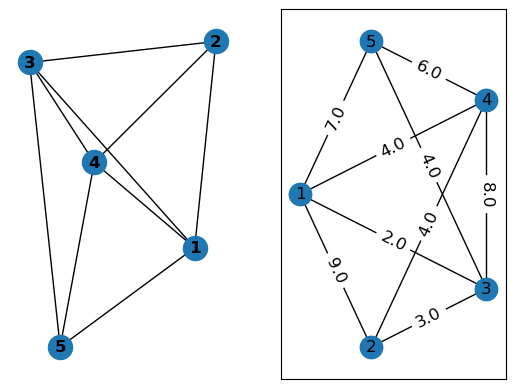

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

a = np.zeros((5, 5))
# 输入邻接矩阵的上三角元素（邻接矩阵对称，只用填入上三角，下三角自动对称补齐）
a[0, 1:5] = [9, 2, 4, 7]  # 第一行
a[1, 2:4] = [3, 4]  # 第二行
a[2, [3, 4]] = [8, 4]  # 第三行
a[3, 4] = 6    # 第四行
np.savetxt("Pdata10_2.txt", a)  # 保存邻接矩阵

i, j = np.nonzero(A)  # 提取顶点的编号，i[k],j[k]表示第k个元素的行、列索引
w = a[i, j]  # 提出a中的非零元素，w长度与i、j相同，一一对应
# zip(i, j, w) 把三个数组按元素配对（组成元组）：(i[k], j[k], w[k])（zip对象），networkx 要求的 (u, v, weight)
edges = list(zip(i, j, w))  

G = nx.Graph()
# 把 edges 里的三元组一次性加到图里，自动把第三个元素存为属性 weight
G.add_weighted_edges_from(edges)

# 把节点 0,1,2,3,4 显示成 “1,2,3,4,5”
key = range(5)
s = [str(i + 1) for i in range(5)]
s = dict(zip(key, s))  # 构造用于顶点标注的字符字典

plt.rcParams['font.size'] = 18
plt.subplot(1, 2, 1)
# nx.draw是networkx对matplotlib的封装，第一个位置参数G指定要画的图，font_weight='bold'节点标签加粗，labels=s将默认的节点标签0~4显示成1~5
nx.draw(G, font_weight='bold', labels=s)
plt.subplot(1, 2, 2)
# 把节点排成同心圆(shell layout)，返回一个dict{node:(x, y)}供后续画图
pos = nx.shell_layout(G)  # 布局设置
# draw_networkx是更底层、更灵活的绘图函数，node_size=260 节点圆直径260像素
nx.draw_networkx(G, pos, node_size=260, labels=s)
# get_edge_attributes(G, name)：返回字典 {(u,v): weight}，把每条边的 weight 属性取出来。
w = nx.get_edge_attributes(G, 'weight')
# font_size=12权重文字大小，edge_labels=w边标签显示边权
nx.draw_networkx_edge_labels(G, pos, font_size=12, edge_labels=w)  # 标注权重
plt.savefig("赋权无向图.png", dpi=500)
plt.show()

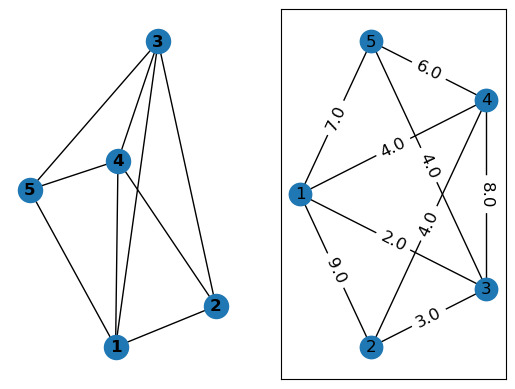

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

a = np.zeros((5, 5))
# 输入邻接矩阵的上三角元素（NetworkX 拿到重复边 → 权重被覆盖但值不变）
a[0, 1:5] = [9, 2, 4, 7]  # 第一行
a[1, 2:4] = [3, 4]  # 第二行
a[2, [3, 4]] = [8, 4]  # 第三行
a[3, 4] = 6    # 第四行
a[1, 0] = 9
a[2, [0, 1]] = [2, 3]
a[3, 0:3] = [4, 4, 8]
a[4, 0:4] = [7, 0, 4, 6]
np.savetxt("Pdata10_2_2.txt", a)  # 保存邻接矩阵

i, j = np.nonzero(A)  # 提取顶点的编号，i[k],j[k]表示第k个元素的行、列索引
w = a[i, j]  # 提出a中的非零元素，w长度与i、j相同，一一对应
# zip(i, j, w) 把三个数组按元素配对（组成元组）：(i[k], j[k], w[k])（zip对象），networkx 要求的 (u, v, weight)
edges = list(zip(i, j, w))  

G = nx.Graph()
# 把 edges 里的三元组一次性加到图里，自动把第三个元素存为属性 weight
G.add_weighted_edges_from(edges)

# 把节点标签 0,1,2,3,4 显示成 “1,2,3,4,5”
key = range(5)
s = [str(i + 1) for i in range(5)]
s = dict(zip(key, s))  # 构造用于顶点标注的字符字典

plt.rcParams['font.size'] = 18
plt.subplot(1, 2, 1)
# nx.draw是networkx对matplotlib的封装，第一个位置参数G指定要画的图，font_weight='bold'节点标签加粗，labels=s将默认的节点标签0~4显示成1~5
nx.draw(G, font_weight='bold', labels=s)
plt.subplot(1, 2, 2)
# 把节点排成同心圆(shell layout)，返回一个dict{node:(x, y)}供后续画图
pos = nx.shell_layout(G)  # 布局设置
# draw_networkx是更底层、更灵活的绘图函数，node_size=260 节点圆直径260像素
nx.draw_networkx(G, pos, node_size=260, labels=s)
# get_edge_attributes(G, name)：返回字典 {(u,v): weight}，把每条边的 weight 属性取出来。
w = nx.get_edge_attributes(G, 'weight')
# font_size=12权重文字大小，edge_labels=w边标签显示边权
nx.draw_networkx_edge_labels(G, pos, font_size=12, edge_labels=w)  # 标注权重
plt.savefig("赋权无向图2.png", dpi=500)
plt.show()

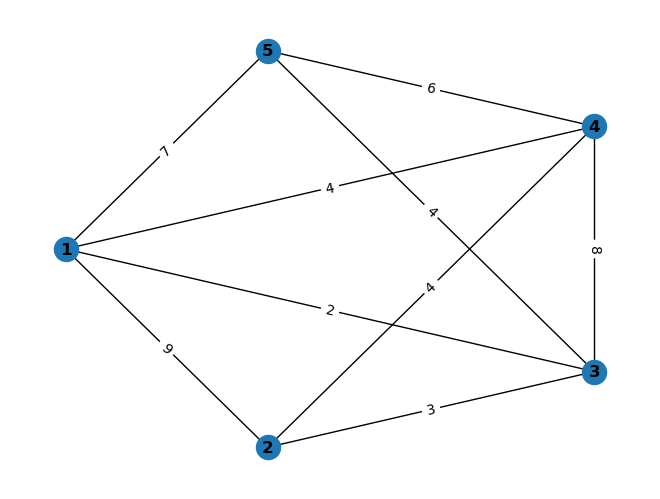

In [13]:
# 上述代码使用了复杂的构造图方法，可直接使用GraphA
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# (i, j, weight)其中，i、j为起点和终点，weight为权
List = [(1, 2, 9), (1, 3, 2), (1, 4, 4), (1, 5, 7), 
        (2, 3, 3), (2, 4, 4), (3, 4, 8), (3, 5, 4), (4, 5, 6)]
G = nx.Graph()  # 空图，点集V和边集E都为空
G.add_nodes_from(range(1, 6))  # 向点集中加入[1, 2, 3, 4, 5]五个顶点
G.add_weighted_edges_from(List)  # 根据 List 一次性批量添加 9 条带权边（默认将第三个元素当作weight）
pos = nx.shell_layout(G)  # pos————position，返回字典{node:(x, y)}
w = nx.get_edge_attributes(G, 'weight')  # 返回字典{(x, y):weight}

# 画出节点和边，但不标权重,with_labels=True,在每个节点旁显示节点id(1~5)
nx.draw(G, pos, with_labels=True, font_weight='bold', font_size=12)
# 在每条边旁写上权重数值
nx.draw_networkx_edge_labels(G, pos, edge_labels=w)  # w为边的权
plt.show()

非赋权有向图的邻接矩阵
$$
\boldsymbol{A} = 
\begin{bmatrix}
0 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 & 0 & 1 \\
0 & 1 & 0 & 1 & 0 & 1 \\
0 & 0 & 0 & 0 & 1 & 0 \\
\end{bmatrix}
$$

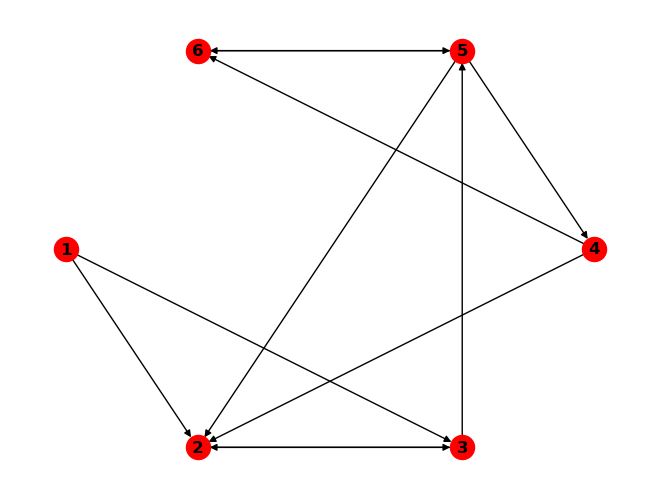

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
List = [(1, 2), (1, 3), (2, 3), (3, 2), (3, 5),
        (4, 2), (4, 6), (5, 2), (5, 4), (5, 6), (6, 5)]  # 没有第三个元素weight，默认为1
G.add_nodes_from(range(1, 7))
G.add_edges_from(List)
pos = nx.shell_layout(G)  # 返回{node:(x, y)}

plt.rcParams['font.size'] = 16
nx.draw(G, pos, with_labels=True, font_weight='bold', node_color='r')
plt.savefig("非赋权有向图.png", dpi=500)
plt.show()

###  4. 图的其他表示和图数据的导出

描述图的方法很多，还可以使用邻接表(adjacency list), 它列出了每个顶点的邻居顶点.

为了使表述更清楚，可以将图表示为列表的字典. 这里，顶点名称就是字典的键，值是顶点的邻接表

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import networkx as nx

a = np.loadtxt("Pdata10_2.txt")
G = nx.Graph(a)  # 利用邻接矩阵构造赋权无向图

print(f"图的顶点集为: {G.nodes()}\n边集为: {G.edges()}")
print(f"邻接表为: {list(G.adjacency())}")  # 显示图的邻接表，node号0~4
print(f"列表字典为: {nx.to_dict_of_lists(G)}")

# to_numpy_matrix, to_scipy_sparse_matrix被移除（ NetworkX 3.0）
B = nx.to_numpy_array(G)  # 从图G中导出邻接矩阵B，这里B=a
# 稀疏矩阵——大部分元素为0，仅有少量非0元素的矩阵
C = nx.to_scipy_sparse_array(G)  # 从图G中导出稀疏矩阵C，sparse——稀疏的(边及其权)
print(f"{B}'\n'{C}")


图的顶点集为: [0, 1, 2, 3, 4]
边集为: [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4)]
邻接表为: [(0, {1: {'weight': 9.0}, 2: {'weight': 2.0}, 3: {'weight': 4.0}, 4: {'weight': 7.0}}), (1, {0: {'weight': 9.0}, 2: {'weight': 3.0}, 3: {'weight': 4.0}}), (2, {0: {'weight': 2.0}, 1: {'weight': 3.0}, 3: {'weight': 8.0}, 4: {'weight': 4.0}}), (3, {0: {'weight': 4.0}, 1: {'weight': 4.0}, 2: {'weight': 8.0}, 4: {'weight': 6.0}}), (4, {0: {'weight': 7.0}, 2: {'weight': 4.0}, 3: {'weight': 6.0}})]
列表字典为: {0: [1, 2, 3, 4], 1: [0, 2, 3], 2: [0, 1, 3, 4], 3: [0, 1, 2, 4], 4: [0, 2, 3]}
[[0. 9. 2. 4. 7.]
 [9. 0. 3. 4. 0.]
 [2. 3. 0. 8. 4.]
 [4. 4. 8. 0. 6.]
 [7. 0. 4. 6. 0.]]'
'  (0, 1)	9.0
  (0, 2)	2.0
  (0, 3)	4.0
  (0, 4)	7.0
  (1, 0)	9.0
  (1, 2)	3.0
  (1, 3)	4.0
  (2, 0)	2.0
  (2, 1)	3.0
  (2, 3)	8.0
  (2, 4)	4.0
  (3, 0)	4.0
  (3, 1)	4.0
  (3, 2)	8.0
  (3, 4)	6.0
  (4, 0)	7.0
  (4, 2)	4.0
  (4, 3)	6.0
